In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import datetime
from IPython.display import display, Math, Latex



# Volatility Modeling & Out-of-Sample Forecasting Framework

This project compares several statistical volatility forecasting approaches for the S&P 500, including naive persistence, Ornstein-Uhlenbeck (OU), EWMA, and GARCH(1,1).

The main objective is to evaluate whether these models improve forecasts of 20-trading-day forward realized volatility relative to a simple persistence benchmark.

Model performance is evaluated out-of-sample using MAE, RMSE, bias, and QLIKE, with additional analysis across normal and high volatility regimes.

In [2]:
start_date = "2000-01-01"
end_date = "2026-01-01"
data = yf.download("^GSPC",
                   start=start_date,
                   end = end_date)

close = data['Close']

print(f"Observations: {len(data)}")
print(f"Start date: {data.index[0].date()}")
print(f"End date: {data.index[-1].date()}")

close.head()


[*********************100%***********************]  1 of 1 completed

Observations: 6539
Start date: 2000-01-03
End date: 2025-12-31


Ticker,^GSPC
Date,
2000-01-03,1455.219971
2000-01-04,1399.420044
2000-01-05,1402.109985
2000-01-06,1403.449951
2000-01-07,1441.469971


## 2. Log Returns

Daily continuously compounded returns are calculated as:

$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

where $(P_t) $ is the S&P 500 closing price on day $(t)$.

In [3]:
log_return = np.log(close/ close.shift(1))
log_return = log_return.dropna(axis=0)
log_return.head()

Ticker,^GSPC
Date,
2000-01-04,-0.039099
2000-01-05,0.001920
2000-01-06,0.000955
2000-01-07,0.026730
2000-01-10,0.011128


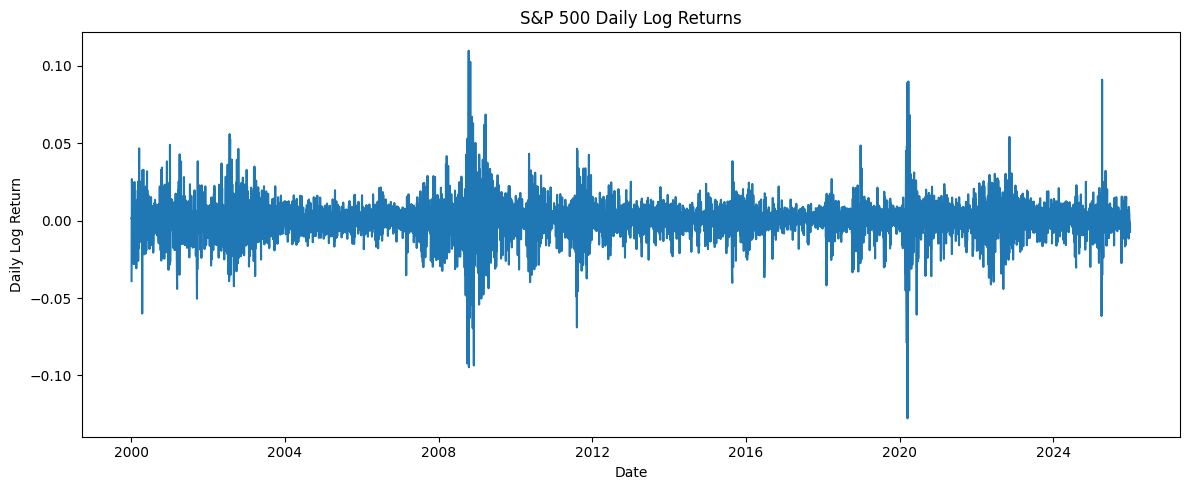

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(log_return.index, log_return.iloc[:, 0])

plt.xlabel("Date")
plt.ylabel("Daily Log Return")
plt.title("S&P 500 Daily Log Returns")
plt.tight_layout()
plt.show()

## 3. Rolling Volatility Proxy

A 40-trading-day rolling standard deviation of daily log returns is used as an annualized volatility proxy:

$$
\sigma_t = SD(r_{t-39}, \ldots, r_t)\sqrt{252}
$$

This series is used to estimate the OU model and provides a backward-looking measure of the current volatility state.

In [5]:
volatility = log_return.rolling(window=40).std()*np.sqrt(252)
volatility = volatility.dropna()

In [6]:
volatility.head()

Ticker,^GSPC
Date,
2000-03-01,0.230706
2000-03-02,0.209306
2000-03-03,0.215175
2000-03-06,0.217580
2000-03-07,0.215601


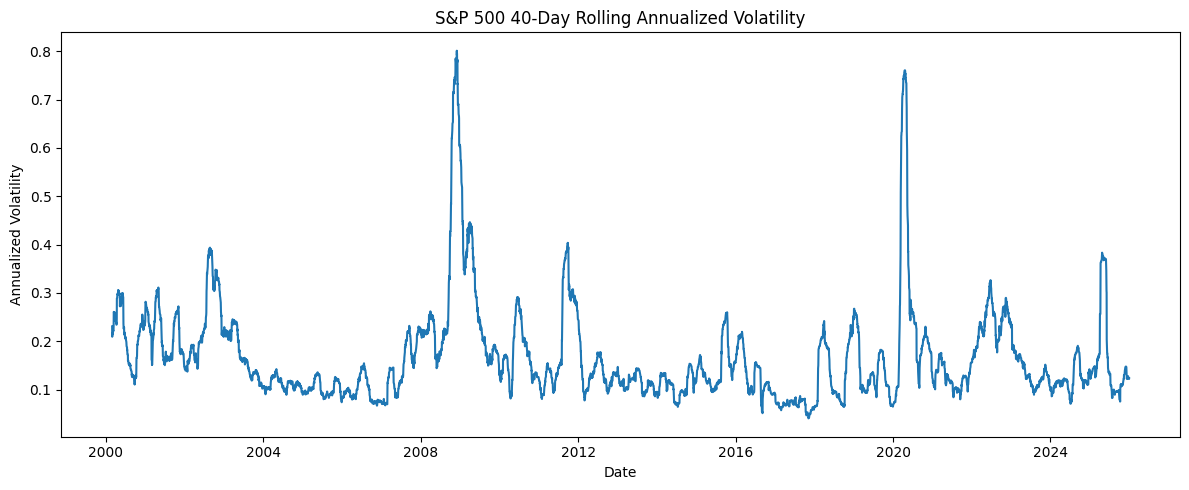

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(volatility.index, volatility.iloc[:, 0])

plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.title("S&P 500 40-Day Rolling Annualized Volatility")
plt.tight_layout()
plt.show()

## 4. Chronological Train-Test Split

The volatility series is divided chronologically into an 80% training sample and a 20% test sample. A chronological split is used instead of random sampling to preserve the time-series structure and prevent future observations from entering the training period.

In [8]:

split_index = int(0.8 * len(volatility))

train = volatility.iloc[:split_index]
test = volatility.iloc[split_index:]

print(f"Training observations: {len(train)}")
print(f"Testing observations: {len(test)}")
print()
print(f"Training period: {train.index[0].date()} to {train.index[-1].date()}")
print(f"Testing period: {test.index[0].date()} to {test.index[-1].date()}")



Training observations: 5199
Testing observations: 1300

Training period: 2000-03-01 to 2020-10-27
Testing period: 2020-10-28 to 2025-12-31


## 5. Ornstein-Uhlenbeck Volatility Model

The Ornstein-Uhlenbeck (OU) process models volatility as a mean-reverting stochastic process:

$$
dX_t = \kappa(\theta - X_t)dt + \sigma dW_t
$$

where:

- $\kappa$ controls the speed of mean reversion,
- $\theta$ represents the long-run mean level,
- $\sigma$ controls the magnitude of random fluctuations,
- $W_t$ is a standard Brownian motion.

Unlike a random walk, the OU process assumes that deviations from the long-run volatility level tend to decay over time.

The model parameters are estimated on the training sample using maximum likelihood estimation (MLE).

In [9]:
def ou_mean(x, dt, kappa, theta):
    e = np.exp(-kappa * dt)
    return (x * e + theta * (1- e) )

def ou_std(dt, kappa, sigma):
    return sigma * np.sqrt(
        (1- np.exp(-2 * kappa * dt)) / (2 * kappa)
    )



In [10]:
x = np.array(train)

In [11]:
x_current = x[:-1]
x_next = x[1:]

In [12]:
print(len(x_current))
print(len(x_next))

5198
5198


In [13]:
print(x.shape)
print(x_current.shape)
print(x_next.shape)

(5199, 1)
(5198, 1)
(5198, 1)


In [14]:
x = np.array(train).flatten()

In [15]:
x_current = x[:-1]
x_next = x[1:]

In [16]:
print(x.shape)
print(x_current.shape)
print(x_next.shape)

(5199,)
(5198,)
(5198,)


In [17]:
from scipy.stats import norm
from scipy.optimize import minimize 
def ou_neg_log_likelihood(params, x):
    kappa, theta, sigma = params

    x_current = x[:-1]
    x_next = x[1:]
    dt = 1/252
    mean = ou_mean(x_current, dt, kappa, theta)

    std = ou_std(dt, kappa, sigma)

    log_likelihood = norm.logpdf(x_next,
                             loc=mean,
                             scale=std)
    

    return -np.sum(log_likelihood)

    

### Maximum Likelihood Estimation

The exact OU transition distribution is Gaussian. Conditional on the current volatility state $X_t$, the next observation satisfies:

$$
X_{t+\Delta t} \mid X_t
\sim
N\left(
X_t e^{-\kappa \Delta t}
+
\theta(1-e^{-\kappa \Delta t}),
\;
\frac{\sigma^2}{2\kappa}
(1-e^{-2\kappa\Delta t})
\right)
$$

The parameters $(\kappa,\theta,\sigma)$ are estimated by minimizing the negative log-likelihood of the observed training volatility series.

The time increment is:

$$
\Delta t = \frac{1}{252}
$$

corresponding to one trading day.

In [18]:
theta_initial = float(train.mean().iloc[0])

initial_params = [1.0, theta_initial, 0.1]
print(initial_params)

bounds = [
    (1e-6, None),  # kappa > 0
    (1e-6, None),  # theta > 0
    (1e-6, None)   # sigma > 0
]


result = minimize(
    ou_neg_log_likelihood,
    x0= initial_params,
    args=(x,),
    method= "L-BFGS-B",
    bounds=bounds
)
print(result)


kappa_hat, theta_hat, sigma_hat = result.x

half_life_years = np.log(2) / kappa_hat





[1.0, 0.16885730659448137, 0.1]
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -18481.35432240912
        x: [ 5.257e-01  1.673e-01  1.098e-01]
      nit: 28
      jac: [ 0.000e+00 -7.276e-04  1.455e-02]
     nfev: 136
     njev: 34
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>


In [19]:

print(f"Kappa: {kappa_hat:.4f}")
print(f"Theta: {theta_hat:.4f}")
print(f"Sigma: {sigma_hat:.4f}")
print(f"Mean-Reversion Half-Life: {half_life_years:.2f} years")

Kappa: 0.5257
Theta: 0.1673
Sigma: 0.1098
Mean-Reversion Half-Life: 1.32 years



### OU Parameter Interpretation

The estimated long-run volatility level is approximately 16.7% annually.

The estimated mean-reversion half-life is approximately 1.32 years, indicating relatively slow mean reversion in the 40-day rolling volatility series.

This slow mean reversion suggests that short-horizon OU forecasts may remain close to the current volatility level, making the model behavior similar to a persistence forecast over short horizons.

In [20]:
test_values = np.array(test).flatten()
last_train_value = x[-1]


### EWMA - Exponentially weighted Moving Average 
 

In [21]:
print(log_return.shape)
print(log_return.tail())

(6538, 1)
Ticker         ^GSPC
Date                
2025-12-24  0.003216
2025-12-26 -0.000304
2025-12-29 -0.003498
2025-12-30 -0.001377
2025-12-31 -0.007385


In [22]:
returns = np.array(log_return).flatten()
print(returns.shape)

(6538,)


In [23]:
train_end_date = train.index[-1]
test_start_date = test.index[0]

print(train_end_date)
print(test_start_date)

2020-10-27 00:00:00
2020-10-28 00:00:00


In [24]:
train_returns = log_return.loc[:train_end_date]
train_returns = np.array(train_returns).flatten()

In [25]:
lambda_ewma = 0.94

# Strarting variance 
ewma_variance = np.var(train_returns)


In [26]:
test_returns = log_return.loc[test.index]
test_returns = np.array(test_returns).flatten()

print(test_returns.shape)

(1300,)


In [27]:
ewma_forecasts = []
for r in test_returns:
    forecast = np.sqrt(ewma_variance) * np.sqrt(252)
    ewma_forecasts.append(forecast)

    ewma_variance = (lambda_ewma * ewma_variance) + ((1-lambda_ewma) * r**2)

In [28]:
ewma_forecasts = np.array(ewma_forecasts)

print(ewma_forecasts.shape)
print(ewma_forecasts[:5])

(1300,)
[0.19953894 0.23862394 0.23591865 0.23360219 0.23143491]


In [29]:
mae_ewma = np.mean(np.abs(ewma_forecasts - test_values))

rmse_ewma = np.sqrt(np.mean((ewma_forecasts - test_values)**2))

bias_ewma = np.mean(ewma_forecasts - test_values)

print("MAE: ", mae_ewma)
print("RMSE: ", rmse_ewma)
print("Bias: ", bias_ewma)

MAE:  0.013886391337860514
RMSE:  0.020503776022417194
Bias:  0.0001648771148648258


In [30]:
%pip install arch


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [31]:
from arch import arch_model


In [32]:
print(train_returns)

garch_train  = train_returns * 100
print(garch_train[:5])
print(garch_train.shape)

[-0.03909918  0.00192034  0.00095522 ...  0.00343984 -0.01876447
 -0.00303021]
[-3.90991753  0.1920338   0.09552217  2.67299497  1.11278249]
(5238,)


In [33]:
garch_model = arch_model(
    garch_train,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
)

In [34]:
garch_result = garch_model.fit(disp='off')
print(garch_result.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -7216.88
Distribution:                  Normal   AIC:                           14441.8
Method:            Maximum Likelihood   BIC:                           14468.0
                                        No. Observations:                 5238
Date:                Tue, Sep 29 2026   Df Residuals:                     5237
Time:                        22:35:41   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0591  1.115e-02      5.300  1.161e-07 [3.

In [35]:
print(garch_result.params)

mu          0.059079
omega       0.022893
alpha[1]    0.125865
beta[1]     0.858457
Name: params, dtype: float64


In [36]:
mu_hat = garch_result.params["mu"]
omega_hat = garch_result.params["omega"]
alpha_hat = garch_result.params["alpha[1]"]
beta_hat = garch_result.params["beta[1]"]

print(mu_hat)
print(omega_hat)
print(alpha_hat)
print(beta_hat)

print()

persistence = alpha_hat + beta_hat
print(persistence)

0.059078543600761126
0.022892972110497078
0.12586474146881926
0.858456783556978

0.9843215250257973


In [37]:
last_cond_vol = garch_result.conditional_volatility[-1]
print(last_cond_vol)

1.0973904876403582


In [38]:
last_variance = (last_cond_vol) **2

In [39]:
last_return = garch_train[-1]

last_residual = last_return - mu_hat

print("Last return:", last_return)
print("last residual:", last_residual)

Last return: -0.3030205350445511
last residual: -0.36209907864531227


In [40]:
first_garch_variance = omega_hat + (alpha_hat * (last_residual)**2 + (beta_hat * last_variance))
print(first_garch_variance)

1.0732060370961594


In [41]:
first_garch_forecast = np.sqrt(first_garch_variance) / 100 * np.sqrt(252)
print('First GARCH variance:', first_garch_variance)
print("First GARCH annualized volatility:", first_garch_forecast)
print("Actual first test volatility:", test_values[0])

First GARCH variance: 1.0732060370961594
First GARCH annualized volatility: 0.16445300889562106
Actual first test volatility: 0.23004492082587233


In [42]:
garch_forecasts = []

current_variance = last_variance
current_residual = last_residual

for r in test_returns:
    forecast_variance=(omega_hat + alpha_hat * current_residual**2 + beta_hat * current_variance)

    forecast_volatility = np.sqrt(forecast_variance) /100 * np.sqrt(252)

    garch_forecasts.append(forecast_volatility)

    current_residual = (r * 100) - mu_hat
    current_variance = forecast_variance

In [43]:
garch_forecasts = np.array(garch_forecasts)

print(garch_forecasts.shape)
print(garch_forecasts[:5])

(1300,)
[0.16445301 0.25707527 0.24768968 0.24173451 0.23462258]


In [44]:
mae_garch = np.mean(np.abs(garch_forecasts - test_values))
rmse_garch = np.sqrt(np.mean((garch_forecasts - test_values)**2))
bias_garch = np.mean(garch_forecasts - test_values)

print("MAE:", mae_garch)
print("RMSE:", rmse_garch)
print("Bias:", bias_garch)

MAE: 0.02679580251357335
RMSE: 0.03983737106937367
Bias: 0.0014861706056336782


## 6. Twenty-Day Forward Realized Volatility

The primary forecasting objective is to predict the realized volatility of the S&P 500 over the next 20 trading days.

For each forecast date $t$, forward realized volatility is calculated from the subsequent 20 daily log returns:

$$
RV_{t,20}
=
\sqrt{
\frac{252}{20}
\sum_{i=1}^{20} r_{t+i}^{2}
}
$$

The factor of 252 annualizes the realized variance.

Importantly, future returns are used only to construct the out-of-sample evaluation target. They are never used as inputs when generating forecasts.

In [45]:
# Building the 20 days target
returns_series = log_return.iloc[:, 0]

In [46]:
future_returns = pd.concat([returns_series.shift(-i) for i in range(1, 21)], axis=1)

print(future_returns.head())
print(future_returns.shape)

               ^GSPC     ^GSPC     ^GSPC     ^GSPC     ^GSPC     ^GSPC  \
Date                                                                     
2000-01-04  0.001920  0.000955  0.026730  0.011128 -0.013149 -0.004396   
2000-01-05  0.000955  0.026730  0.011128 -0.013149 -0.004396  0.012096   
2000-01-06  0.026730  0.011128 -0.013149 -0.004396  0.012096  0.010615   
2000-01-07  0.011128 -0.013149 -0.004396  0.012096  0.010615 -0.006856   
2000-01-10 -0.013149 -0.004396  0.012096  0.010615 -0.006856  0.000522   

               ^GSPC     ^GSPC     ^GSPC     ^GSPC     ^GSPC     ^GSPC  \
Date                                                                     
2000-01-04  0.012096  0.010615 -0.006856  0.000522 -0.007121 -0.002917   
2000-01-05  0.010615 -0.006856  0.000522 -0.007121 -0.002917 -0.028023   
2000-01-06 -0.006856  0.000522 -0.007121 -0.002917 -0.028023  0.006046   
2000-01-07  0.000522 -0.007121 -0.002917 -0.028023  0.006046 -0.004222   
2000-01-10 -0.007121 -0.002917 -0.028

In [47]:
forward_vol_20 = future_returns.std(axis=1, skipna=False)* np.sqrt(252)

forward_vol_20 = forward_vol_20.dropna()

In [48]:
print(forward_vol_20.shape)
print(forward_vol_20.head())
print(forward_vol_20.tail())

(6518,)
Date
2000-01-04    0.223332
2000-01-05    0.226596
2000-01-06    0.226637
2000-01-07    0.204786
2000-01-10    0.205633
dtype: float64
Date
2025-11-25    0.091265
2025-11-26    0.088877
2025-11-28    0.088496
2025-12-01    0.086169
2025-12-02    0.090352
dtype: float64


In [49]:
forward_test = forward_vol_20.loc[test_start_date:]

print(forward_test.shape)
print(forward_test.index[0])
print(forward_test.index[-1])

(1280,)
2020-10-28 00:00:00
2025-12-02 00:00:00


In [50]:
current_vol = volatility.loc[test_start_date].iloc[0]
print(current_vol)

0.23004492082587233


In [51]:
horizons = np.arange(1,21)
print(horizons)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


In [52]:
dt_horizons = (1/252) * horizons
print(dt_horizons)

[0.00396825 0.00793651 0.01190476 0.01587302 0.01984127 0.02380952
 0.02777778 0.03174603 0.03571429 0.03968254 0.04365079 0.04761905
 0.0515873  0.05555556 0.05952381 0.06349206 0.06746032 0.07142857
 0.07539683 0.07936508]


In [53]:
# Generatung the OU expected volatility path for those 20 future days
ou_20_paths = ou_mean(
    current_vol,
    dt_horizons,
    kappa_hat,
    theta_hat,

)
print(ou_20_paths)

[0.22991414 0.22978363 0.22965339 0.22952342 0.22939373 0.2292643
 0.22913515 0.22900626 0.22887764 0.22874929 0.22862121 0.22849339
 0.22836584 0.22823856 0.22811154 0.22798479 0.2278583  0.22773207
 0.22760611 0.22748041]


In [54]:
ou_20_forecasts = np.sqrt((1/20)*(np.sum(ou_20_paths**2)))
print(ou_20_forecasts)

0.22869085207749584


In [55]:
ou_20_forecasts = []

for date in forward_test.index:
    current_vol = volatility.loc[date].iloc[0]

    ou_path = ou_mean(
        current_vol,
        dt_horizons,
        kappa_hat,
        theta_hat
    )

    forecast = np.sqrt(np.mean(ou_path **2))

    ou_20_forecasts.append(forecast)

In [56]:
ou_20_forecasts = np.array(ou_20_forecasts)

print(ou_20_forecasts.shape)
print(ou_20_forecasts[:5])

(1280,)
[0.22869085 0.22725091 0.21221073 0.21411435 0.2073321 ]


In [57]:
actual_20_vol = forward_test.to_numpy()
print(actual_20_vol.shape)
print(actual_20_vol[:5])

(1280,)
[0.17009474 0.16848201 0.16031615 0.15974633 0.15294552]


In [58]:
errors = actual_20_vol- ou_20_forecasts

In [59]:
mae_ou_20 = np.mean(np.abs(errors))
rmse_ou_20 = np.sqrt(np.mean(errors **2))
bias_ou_20 = np.mean(errors)

print("MAE:", mae_ou_20)
print("RMSE:", rmse_ou_20)
print("BIAS:", bias_ou_20)




MAE: 0.04903963740010483
RMSE: 0.07223647771936881
BIAS: -0.004958865197266321


In [60]:
# Building the naive predictions without a loop. 
forward_test.index

DatetimeIndex(['2020-10-28', '2020-10-29', '2020-10-30', '2020-11-02',
               '2020-11-03', '2020-11-04', '2020-11-05', '2020-11-06',
               '2020-11-09', '2020-11-10',
               ...
               '2025-11-18', '2025-11-19', '2025-11-20', '2025-11-21',
               '2025-11-24', '2025-11-25', '2025-11-26', '2025-11-28',
               '2025-12-01', '2025-12-02'],
              dtype='datetime64[s]', name='Date', length=1280, freq=None)

In [61]:
naive_20_forecast = volatility.loc[forward_test.index]
print(naive_20_forecast.shape)
print(naive_20_forecast.head())

(1280, 1)
Ticker         ^GSPC
Date                
2020-10-28  0.230045
2020-10-29  0.228573
2020-10-30  0.213202
2020-11-02  0.215147
2020-11-03  0.208215


In [62]:
actual_20_vol.shape

(1280,)

In [63]:
naive_20_forecast = np.array(naive_20_forecast).flatten()
print(naive_20_forecast)
print(naive_20_forecast.shape)

[0.23004492 0.22857325 0.21320159 ... 0.1469287  0.14765436 0.14751398]
(1280,)


In [64]:
naive_errors = actual_20_vol - naive_20_forecast 

In [65]:
mae_naive_20 = np.mean(np.abs(naive_errors))
rmse_naive_20 = np.sqrt(np.mean((naive_errors**2)))
bias_naive_20 = np.mean(naive_errors)

print("mae_naive_20:", mae_naive_20)
print("rmse_naive_20:", rmse_naive_20)
print("bias_naive_20:", bias_naive_20)

mae_naive_20: 0.04935969591857792
rmse_naive_20: 0.07285879470101236
bias_naive_20: -0.004765884675170327


### OU modestly improves forecast accuracy relative to the persistence benchmark, but the improvement is very small.

In [66]:
train_returns

array([-0.03909918,  0.00192034,  0.00095522, ...,  0.00343984,
       -0.01876447, -0.00303021], shape=(5238,))

In [67]:
ewma_variance

np.float64(4.3879770299547365e-05)

In [68]:
ewma_variance = np.var(train_returns[:40])
print(ewma_variance)

0.00020593185968526906


In [69]:
for r in train_returns[40:]:
    ewma_variance = lambda_ewma * ewma_variance + (1- lambda_ewma) * r**2

In [70]:
print(ewma_variance)
print(np.sqrt(ewma_variance) * np.sqrt(252))

0.00012218670857364798
0.1754737888134843


In [71]:
ewma_test_returns = returns_series.loc[forward_test.index]

print(ewma_test_returns.shape)
print(ewma_test_returns[:5])

(1280,)
Date
2020-10-28   -0.035926
2020-10-29    0.011877
2020-10-30   -0.012204
2020-11-02    0.012243
2020-11-03    0.017643
Name: ^GSPC, dtype: float64


In [72]:
ewma_20_forecast = []

for r in ewma_test_returns:
    ewma_variance = (lambda_ewma * ewma_variance) + (1-lambda_ewma) * r**2
    forecast = np.sqrt(ewma_variance) * np.sqrt(252)
    ewma_20_forecast.append(forecast)

In [73]:
ewma_20_forecast[:4]

[np.float64(0.2201320819711408),
 np.float64(0.21836517440582384),
 np.float64(0.21696584853870776),
 np.float64(0.21567582883906325)]

In [74]:
ewma_20_forecast = np.array(ewma_20_forecast)

print(ewma_20_forecast.shape)
print(ewma_20_forecast[:5])

(1280,)
[0.22013208 0.21836517 0.21696585 0.21567583 0.22007145]


In [75]:
ewma_error = actual_20_vol - ewma_20_forecast

In [76]:
mae_ewma_20 = np.mean(np.abs(ewma_error))
rmse_ewma_20 = np.sqrt(np.mean(ewma_error**2))
bias_ewma_20 = np.mean(ewma_error)

print("MAE:", mae_ewma_20)
print("RMSE:", rmse_ewma_20)
print("Bias:", bias_ewma_20)

MAE: 0.046655496426289134
RMSE: 0.06814180340210561
Bias: -0.004750240090665424


In [77]:
print(omega_hat)
print(alpha_hat)
print(beta_hat)
print(mu_hat)
print(last_variance)
print(last_residual)

0.022892972110497078
0.12586474146881926
0.858456783556978
0.059078543600761126
1.204265882363543
-0.36209907864531227


In [78]:
garch_persistence = alpha_hat + beta_hat
print(garch_persistence)

0.9843215250257973


In [79]:
first_return = ewma_test_returns.iloc[0]

In [80]:
first_residual = (first_return * 100) - mu_hat
print(first_return)
print(first_residual)

-0.03592554210857772
-3.651632754458533


In [81]:
first_current_variance = omega_hat + (alpha_hat * last_residual**2 ) + (beta_hat * last_variance) 
print(first_current_variance)

1.0732060370961594


In [82]:
first_future_variance = (omega_hat + alpha_hat * first_residual**2 + beta_hat * first_current_variance)
print(first_future_variance)

2.622527523959514


In [83]:
second_future_variance = omega_hat + garch_persistence * first_future_variance
print(second_future_variance)

2.604303263916454


In [84]:
variance_path = [first_future_variance]

In [85]:
for i in range(19):
    next_variance = omega_hat + garch_persistence *variance_path[-1]
    variance_path.append(next_variance)

print(len(variance_path))
print(variance_path[:5])
print(variance_path[-5:])

20
[np.float64(2.622527523959514), np.float64(2.604303263916454), np.float64(2.5863647324784025), np.float64(2.5687074498565763), np.float64(2.551327006498449)]
[np.float64(2.377219473234243), np.float64(2.36284126932545), np.float64(2.3486884937268147), np.float64(2.334757612066218), np.float64(2.3210451453851055)]


In [86]:
variance_path = np.array(variance_path)

In [87]:
garch_first_20_forecast = (np.sqrt(np.mean(variance_path)) / 100 * np.sqrt(252))
print(garch_first_20_forecast)

0.24921717132583537


In [88]:
garch_20_forecasts = []

current_variance = last_variance
current_residual = last_residual


for r in ewma_test_returns:

    # Today's variance
    today_variance = omega_hat + alpha_hat *current_residual**2 + beta_hat * current_variance 
    
    # Today's shock
    today_residual = r*100 - mu_hat

    # Day 1 future variance
    first_future_variance = omega_hat + alpha_hat * today_residual**2 + beta_hat * today_variance

    # Days 1-20
    variance_path = [first_future_variance]
    for i in range(19):
        next_variance = omega_hat + garch_persistence * variance_path[-1] 
        variance_path.append(next_variance)
    
    # Converting the 20 variances into one volatility forecast
    forecast = np.sqrt(np.mean(variance_path)) / 100 * np.sqrt(252)
    garch_20_forecasts.append(forecast)

    # Carry today's state into tomorrow
    current_variance = today_variance
    current_residual = today_residual


    
garch_20_forecasts = np.array(garch_20_forecasts)
print(garch_20_forecasts.shape)
print(garch_20_forecasts[:5])

(1280,)
[0.24921717 0.24086333 0.23557676 0.22927872 0.23303192]


In [89]:
garch_errors = actual_20_vol - garch_20_forecasts

mae_garch_20 = np.mean(np.abs(garch_errors))
rmse_garch_20 = np.sqrt(np.mean(garch_errors**2))
bias_garch_20 = np.mean(garch_errors)

print("MAE:", mae_garch_20)
print("RMSE:", rmse_garch_20)
print("Bias:", bias_garch_20)

MAE: 0.045354414615202475
RMSE: 0.06497642789961447
Bias: -0.012617054086557949


In [90]:
forward_var_20 = ((future_returns**2).mean(axis=1, skipna=False) * 252)
forward_vol_20 = np.sqrt(forward_var_20)
forward_vol_20 = forward_vol_20.dropna()

In [91]:
# Recreating our test target
forward_test = forward_vol_20.loc[test_start_date:]
actual_20_vol = forward_test.to_numpy()

print(forward_test.shape)
print(actual_20_vol[:5])

(1280,)
[0.18521282 0.18055126 0.17603851 0.17516789 0.16371373]


In [92]:
# Recalculating all four error sets against actual_20_vol

naive_errors = actual_20_vol - naive_20_forecast
ou_errors = actual_20_vol - ou_20_forecasts
ewma_errors = actual_20_vol - ewma_20_forecast
garch_errors = actual_20_vol - garch_20_forecasts

In [93]:
print("Naive")
print(f"MAE: {np.mean(np.abs(naive_errors))}")
print(f"RMSE: {np.sqrt(np.mean(naive_errors**2))}")
print(f"Bias: {np.mean(naive_errors)}")
print("*" * 30)

print("OU")
print(f"MAE: {np.mean(np.abs(ou_errors))}")
print(f"RMSE: {np.sqrt(np.mean(ou_errors**2))}")
print(f"Bias: {np.mean(ou_errors)}")
print("*" * 30)

print("EWMA")
print(f"MAE: {np.mean(np.abs(ewma_errors))}")
print(f"RMSE: {np.sqrt(np.mean(ewma_errors**2))}")
print(f"Bias: {np.mean(ewma_errors)}")
print("*" * 30)

print("GARCH")
print(f"MAE: {np.mean(np.abs(garch_errors))}")
print(f"RMSE: {np.sqrt(np.mean(garch_errors**2))}")
print(f"Bias: {np.mean(garch_errors)}")
print("*" * 30)

Naive
MAE: 0.04784135234211488
RMSE: 0.07114501042918711
Bias: -0.004990397772504257
******************************
OU
MAE: 0.04751003878486969
RMSE: 0.07051313310528155
Bias: -0.005183378294600255
******************************
EWMA
MAE: 0.045073455312639635
RMSE: 0.06631030285535398
Bias: -0.004974753187999354
******************************
GARCH
MAE: 0.04397340554768192
RMSE: 0.06320579582354917
Bias: -0.012841567183891883
******************************


# Visualization of actual 20-days forward realized volatility

In [94]:
print(forward_test.index)
print(actual_20_vol)

DatetimeIndex(['2020-10-28', '2020-10-29', '2020-10-30', '2020-11-02',
               '2020-11-03', '2020-11-04', '2020-11-05', '2020-11-06',
               '2020-11-09', '2020-11-10',
               ...
               '2025-11-18', '2025-11-19', '2025-11-20', '2025-11-21',
               '2025-11-24', '2025-11-25', '2025-11-26', '2025-11-28',
               '2025-12-01', '2025-12-02'],
              dtype='datetime64[s]', name='Date', length=1280, freq=None)
[0.18521282 0.18055126 0.17603851 ... 0.08650274 0.08454369 0.08808462]


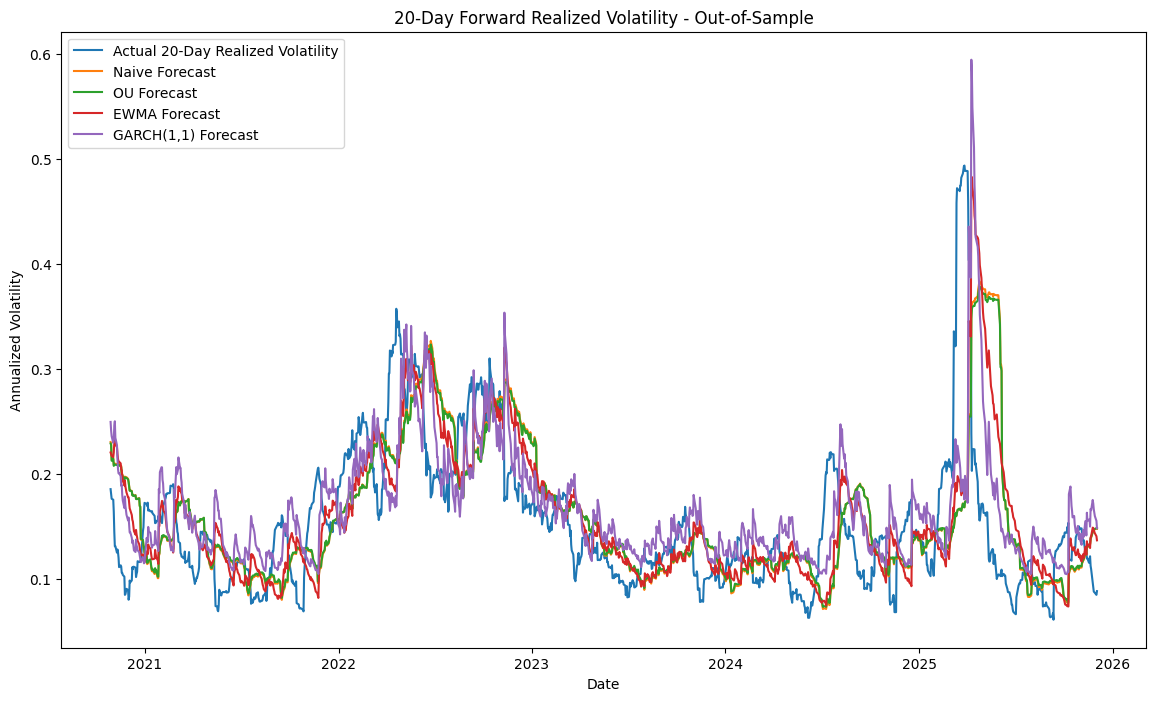

In [95]:
plt.figure(figsize=(14, 8))

plt.plot(forward_test.index, 
         actual_20_vol,
         label="Actual 20-Day Realized Volatility")

plt.plot(forward_test.index,
         naive_20_forecast,
         label ="Naive Forecast")

plt.plot(forward_test.index,
         ou_20_forecasts,
         label ="OU Forecast")

plt.plot(forward_test.index,
         ewma_20_forecast,
         label ="EWMA Forecast")


plt.plot(forward_test.index,
         garch_20_forecasts,
         label='GARCH(1,1) Forecast')





plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.title("20-Day Forward Realized Volatility - Out-of-Sample")

plt.legend()
plt.show()

In [96]:
forward_test.index

DatetimeIndex(['2020-10-28', '2020-10-29', '2020-10-30', '2020-11-02',
               '2020-11-03', '2020-11-04', '2020-11-05', '2020-11-06',
               '2020-11-09', '2020-11-10',
               ...
               '2025-11-18', '2025-11-19', '2025-11-20', '2025-11-21',
               '2025-11-24', '2025-11-25', '2025-11-26', '2025-11-28',
               '2025-12-01', '2025-12-02'],
              dtype='datetime64[s]', name='Date', length=1280, freq=None)

In [97]:
quarters = forward_test.index.to_period("Q")

print(quarters[:10])
print(quarters.unique())

PeriodIndex(['2020Q4', '2020Q4', '2020Q4', '2020Q4', '2020Q4', '2020Q4',
             '2020Q4', '2020Q4', '2020Q4', '2020Q4'],
            dtype='period[Q-DEC]', name='Date')
PeriodIndex(['2020Q4', '2021Q1', '2021Q2', '2021Q3', '2021Q4', '2022Q1',
             '2022Q2', '2022Q3', '2022Q4', '2023Q1', '2023Q2', '2023Q3',
             '2023Q4', '2024Q1', '2024Q2', '2024Q3', '2024Q4', '2025Q1',
             '2025Q2', '2025Q3', '2025Q4'],
            dtype='period[Q-DEC]', name='Date')


In [98]:
unique_quarters = quarters.unique()

quarter = unique_quarters[0]

print(quarter)
print(quarter.start_time)

2020Q4
2020-10-01 00:00:00


In [99]:
for quarter in unique_quarters[:5]:
    print(quarter, quarter.start_time)

2020Q4 2020-10-01 00:00:00
2021Q1 2021-01-01 00:00:00
2021Q2 2021-04-01 00:00:00
2021Q3 2021-07-01 00:00:00
2021Q4 2021-10-01 00:00:00


In [100]:
quarter = unique_quarters[1]

quarter_start = quarter.start_time

expanding_train = volatility.loc[volatility.index < quarter_start]

print("Quarter:", quarter)
print("Quarter starts:", quarter_start)
print("Training starts:", expanding_train.index[0])
print("Training ends:", expanding_train.index[-1])
print("Observation:", len(expanding_train))

Quarter: 2021Q1
Quarter starts: 2021-01-01 00:00:00
Training starts: 2000-03-01 00:00:00
Training ends: 2020-12-31 00:00:00
Observation: 5244


In [101]:
# Re-estimating OU for 2021 Q1 
x_expanding = np.array(expanding_train).flatten()

print(x_expanding.shape)

(5244,)


In [102]:
# Creating starting guesses. for that we are using our previous OU estites as the starting point for the optimizer

initial_params = [kappa_hat, theta_hat, sigma_hat]

In [103]:
result = minimize(
    fun=ou_neg_log_likelihood,
    x0 = initial_params,
    args = (x_expanding,),
    method = "L-BFGS-B",
    bounds= bounds 
)


In [104]:
print(result.success)
print(result.message)

True
CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


In [105]:
kappa_new, theta_new, sigma_new = result.x

print("Old Parameters:")
print("Kappa:", kappa_hat)
print("Theta:", theta_hat)
print("Sigma:", sigma_hat)

print("\n2021 Q1 re-estimated parameters:")
print("Kappa:", kappa_new)
print("Theta:", theta_new)
print("Sigma:", sigma_new)


Old Parameters:
Kappa: 0.5256558428493999
Theta: 0.16728227381032235
Sigma: 0.10984825516479986

2021 Q1 re-estimated parameters:
Kappa: 0.5288232487579893
Theta: 0.15927681025660062
Sigma: 0.10977468836698757


In [106]:
ou_quarterly_params = []

In [107]:
for quarter in unique_quarters:
    if quarter == unique_quarters[0]:
        kappa_q = kappa_hat
        theta_q  = theta_hat
        sigma_q = sigma_hat

    else:
        quarter_start = quarter.start_time

        expanding_train = volatility.loc[
            volatility.index < quarter_start
        ]
        x_expanding = np.array(expanding_train).flatten()
        initial_params =[kappa_q,
                         theta_q,
                         sigma_q]
        
        result = minimize(
            fun=ou_neg_log_likelihood,
            x0=initial_params,
            args=(x_expanding, ),
            method="L-BFGS-B",
            bounds=bounds
        )
        kappa_q, theta_q, sigma_q= result.x

    
    ou_quarterly_params.append([quarter, kappa_q, theta_q, sigma_q])

print(len(ou_quarterly_params))
print(ou_quarterly_params[:3])



    

21
[[Period('2020Q4', 'Q-DEC'), np.float64(0.5256558428493999), np.float64(0.16728227381032235), np.float64(0.10984825516479986)], [Period('2021Q1', 'Q-DEC'), np.float64(0.5288232487579893), np.float64(0.15927681025660062), np.float64(0.10977468836698757)], [Period('2021Q2', 'Q-DEC'), np.float64(0.5291833234096255), np.float64(0.16147557023636772), np.float64(0.10945148520906187)]]


In [108]:
print(ou_quarterly_params)

[[Period('2020Q4', 'Q-DEC'), np.float64(0.5256558428493999), np.float64(0.16728227381032235), np.float64(0.10984825516479986)], [Period('2021Q1', 'Q-DEC'), np.float64(0.5288232487579893), np.float64(0.15927681025660062), np.float64(0.10977468836698757)], [Period('2021Q2', 'Q-DEC'), np.float64(0.5291833234096255), np.float64(0.16147557023636772), np.float64(0.10945148520906187)], [Period('2021Q3', 'Q-DEC'), np.float64(0.5298026252221582), np.float64(0.16074916821228238), np.float64(0.10896587916924688)], [Period('2021Q4', 'Q-DEC'), np.float64(0.5302172458852644), np.float64(0.16006464935387132), np.float64(0.10850929507636492)], [Period('2022Q1', 'Q-DEC'), np.float64(0.531104230497512), np.float64(0.16105898987311454), np.float64(0.10805400491593391)], [Period('2022Q2', 'Q-DEC'), np.float64(0.5311018031159398), np.float64(0.16736047444389887), np.float64(0.1076634374732387)], [Period('2022Q3', 'Q-DEC'), np.float64(0.5300830126648619), np.float64(0.1752309080657978), np.float64(0.1075574

In [109]:
ou_params_df = pd.DataFrame(ou_quarterly_params,
                            columns=["Quarter", "Kappa", "Theta", "Sigma"])

print(ou_params_df)

   Quarter     Kappa     Theta     Sigma
0   2020Q4  0.525656  0.167282  0.109848
1   2021Q1  0.528823  0.159277  0.109775
2   2021Q2  0.529183  0.161476  0.109451
3   2021Q3  0.529803  0.160749  0.108966
4   2021Q4  0.530217  0.160065  0.108509
5   2022Q1  0.531104  0.161059  0.108054
6   2022Q2  0.531102  0.167360  0.107663
7   2022Q3  0.530083  0.175231  0.107557
8   2022Q4  0.530370  0.168256  0.107707
9   2023Q1  0.530663  0.170058  0.107765
10  2023Q2  0.530800  0.169996  0.107725
11  2023Q3  0.544949  0.160909  0.107320
12  2023Q4  0.545179  0.160193  0.106843
13  2024Q1  0.545128  0.159540  0.106409
14  2024Q2  0.545135  0.158943  0.106011
15  2024Q3  0.544454  0.158294  0.105585
16  2024Q4  0.544639  0.162000  0.105329
17  2025Q1  0.544938  0.161713  0.105158
18  2025Q2  0.545534  0.162782  0.104916
19  2025Q3  0.545537  0.162778  0.109148
20  2025Q4  0.570543  0.156415  0.108828


In [110]:
ou_quarterly_forecasts = []

for i, quarter in enumerate(unique_quarters):

    kappa_q = ou_params_df.loc[i, "Kappa"]
    theta_q = ou_params_df.loc[i, "Theta"]

    quarter_mask = quarters ==quarter
    quarter_dates = forward_test.index[quarter_mask]

    for date in quarter_dates:
        current_vol = volatility.loc[date].iloc[0]
        ou_path = ou_mean(
            current_vol,
            dt_horizons,
            kappa_q,
            theta_q
        )

        forecast = np.sqrt(np.mean(ou_path **2))
        ou_quarterly_forecasts.append(forecast) 

ou_quarterly_forecasts = np.array(ou_quarterly_forecasts)
print(ou_quarterly_forecasts.shape)
print(ou_quarterly_forecasts[:5])


print(quarter, len(quarter_dates), quarter_dates[0], quarter_dates[-1])

(1280,)
[0.22869085 0.22725091 0.21221073 0.21411435 0.2073321 ]
2025Q4 44 2025-10-01 00:00:00 2025-12-02 00:00:00


In [111]:
np.allclose(
    ou_quarterly_forecasts[:45],
    ou_20_forecasts[:45]
)

True

In [112]:
np.allclose(
    ou_quarterly_forecasts,
    ou_20_forecasts
)


False

In [113]:

ou_quarterly_mae = np.mean(np.abs(actual_20_vol - ou_quarterly_forecasts))
ou_quarterly_rmse = np.sqrt(np.mean((actual_20_vol - ou_quarterly_forecasts)**2))
ou_quarterly_bias = np.mean((actual_20_vol - ou_quarterly_forecasts))

print("Quarterly OU MAE:", ou_quarterly_mae)
print("Quarterly OU RMSE:", ou_quarterly_rmse)
print("Quarterly OU Bias:", ou_quarterly_bias)

Quarterly OU MAE: 0.04751026404660075
Quarterly OU RMSE: 0.0704998463765603
Quarterly OU Bias: -0.005101568269089776


## GARCH quarterly re-estimation


In [114]:
quarter = unique_quarters[1]
quarter_start = quarter.start_time

print(quarter)
print(quarter_start)

2021Q1
2021-01-01 00:00:00


In [115]:
garch_expanding_train = (returns_series.loc[returns_series.index < quarter_start] * 100)

print(garch_expanding_train.index[0])
print(garch_expanding_train.index[-1])
print(len(garch_expanding_train)) 

2000-01-04 00:00:00
2020-12-31 00:00:00
5283


In [116]:
garch_model = arch_model(
    garch_expanding_train,
    mean ="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
)

In [117]:
garch_result_q = garch_model.fit(disp="off")

In [118]:
mu_q = garch_result_q.params["mu"]
omega_q = garch_result_q.params["omega"]
alpha_q = garch_result_q.params["alpha[1]"]
beta_q = garch_result_q.params["beta[1]"]

print("mu:", mu_q)
print("omega:", omega_q)
print("alpha:", alpha_q)
print("beta:", beta_q)
print("persistence:", alpha_q + beta_q)

mu: 0.060496291127263714
omega: 0.023018512156605598
alpha: 0.12668130276980827
beta: 0.8574827715680046
persistence: 0.9841640743378128


In [119]:
last_variance_q =  garch_result_q.conditional_volatility.iloc[-1] ** 2
last_residual_q = garch_result_q.resid.iloc[-1]

In [120]:
print("Last variance:", last_variance_q)
print("Last residual:", last_residual_q)

Last variance: 0.37188159983021735
Last residual: 0.5813241800431156


In [121]:
garch_quarterly_params =[]
for quarter in unique_quarters:
    if quarter == unique_quarters[0]:
        mu_q = mu_hat
        omega_q = omega_hat
        alpha_q = alpha_hat
        beta_q = beta_hat
    else:
        quarter_start = quarter.start_time

        garch_expanding_train = (returns_series.loc[returns_series.index < quarter_start] * 100)

        garch_model_q = arch_model(
            garch_expanding_train,
            mean="Constant",
            vol="GARCH",
            p=1,
            q=1,
            dist="normal")
        
        garch_result_q = garch_model_q.fit(disp="off")


        mu_q = garch_result_q.params["mu"]
        omega_q = garch_result_q.params["omega"]
        alpha_q = garch_result_q.params["alpha[1]"]
        beta_q = garch_result_q.params["beta[1]"]

    
    garch_quarterly_params.append([quarter, mu_q, omega_q, alpha_q, beta_q])
        


        

        

In [122]:
print(len(garch_quarterly_params))
print(garch_quarterly_params[:3])

21
[[Period('2020Q4', 'Q-DEC'), np.float64(0.059078543600761126), np.float64(0.022892972110497078), np.float64(0.12586474146881926), np.float64(0.858456783556978)], [Period('2021Q1', 'Q-DEC'), np.float64(0.060496291127263714), np.float64(0.023018512156605598), np.float64(0.12668130276980827), np.float64(0.8574827715680046)], [Period('2021Q2', 'Q-DEC'), np.float64(0.05974996926775384), np.float64(0.023329350141189576), np.float64(0.12571815334052125), np.float64(0.8581506529745027)]]


In [123]:
garch_params_df = pd.DataFrame(garch_quarterly_params, columns=["Quarter", "Mu", "Omega", "Alpha", "Beta" ])

garch_params_df["Persistence"] = (garch_params_df["Alpha"] + garch_params_df["Beta"])

print(garch_params_df)

   Quarter        Mu     Omega     Alpha      Beta  Persistence
0   2020Q4  0.059079  0.022893  0.125865  0.858457     0.984322
1   2021Q1  0.060496  0.023019  0.126681  0.857483     0.984164
2   2021Q2  0.059750  0.023329  0.125718  0.858151     0.983869
3   2021Q3  0.060851  0.023592  0.126568  0.856836     0.983403
4   2021Q4  0.060360  0.023753  0.127151  0.856112     0.983263
5   2022Q1  0.061159  0.024472  0.126731  0.855475     0.982206
6   2022Q2  0.060174  0.024163  0.125898  0.856833     0.982731
7   2022Q3  0.059255  0.024015  0.126762  0.856726     0.983488
8   2022Q4  0.058589  0.023584  0.125445  0.858625     0.984070
9   2023Q1  0.058742  0.023097  0.124031  0.860565     0.984596
10  2023Q2  0.058904  0.022932  0.122995  0.861615     0.984609
11  2023Q3  0.060124  0.022968  0.122281  0.861950     0.984232
12  2023Q4  0.058693  0.022800  0.121287  0.862791     0.984078
13  2024Q1  0.060054  0.022852  0.121195  0.862614     0.983809
14  2024Q2  0.061195  0.022696  0.119945

In [124]:
quarter = unique_quarters[1]
quarter_start = quarter.start_time

In [125]:
current_variance = (garch_result_q.conditional_volatility.iloc[-1] **2)
current_residual = garch_result_q.resid.iloc[-1]

In [126]:
quarter_dates = forward_test.index[quarters == quarter]
quarter_returns = returns_series.loc[quarter_dates]

print(quarter_dates[0], quarter_dates[-1])
print(len(quarter_returns))

2021-01-04 00:00:00 2021-03-31 00:00:00
61


In [127]:
print(quarter_returns)

Date
2021-01-04   -0.014865
2021-01-05    0.007058
2021-01-06    0.005694
2021-01-07    0.014738
2021-01-08    0.005477
                ...   
2021-03-25    0.005227
2021-03-26    0.016494
2021-03-29   -0.000868
2021-03-30   -0.003163
2021-03-31    0.003616
Name: ^GSPC, Length: 61, dtype: float64


In [128]:
garch_q1_forecast = []
persistence_q = alpha_q + beta_q

for r in quarter_returns:
    today_variance = (omega_q + alpha_q * current_residual**2 + beta_q * current_variance)
    today_residual = r * 100 - mu_q

    first_future_variance = (omega_q + alpha_q * today_residual**2 + beta_q * today_variance)
    
    variance_path = [first_future_variance]

    for i in range(19):
        next_variance = omega_q + persistence_q * variance_path[-1]
        variance_path.append(next_variance)

    
    forecast = (np.sqrt(np.mean(variance_path))/ 100 * np.sqrt(252))
    garch_q1_forecast.append(forecast)

    current_variance = today_variance
    current_residual = today_residual


garch_q1_forecast = np.array(garch_q1_forecast)

print(garch_q1_forecast.shape)
print(garch_q1_forecast[:5])




(61,)
[0.13484419 0.13401982 0.13174885 0.14632131 0.14235706]


In [129]:
garch_quarterly_forecasts = []

for quarter in unique_quarters:
    quarter_dates = forward_test.index[quarters == quarter]

    if quarter == unique_quarters[0]:
        mu_q = mu_hat
        omega_q = omega_hat
        alpha_q = alpha_hat
        beta_q = beta_hat

        current_variance = (garch_result.conditional_volatility[-1] **2)
        current_residual = garch_result.resid[-1]

        

    else:
        quarter_start = quarter.start_time

        garch_expanding_train = (returns_series.loc[returns_series.index < quarter_start] * 100)

        garch_model_q = arch_model(
            garch_expanding_train,
            mean="Constant",
            vol="GARCH",
            p=1,
            q=1,
            dist="normal"
        )

        garch_result_q = garch_model_q.fit(disp="off")

        mu_q = garch_result_q.params["mu"]
        omega_q = garch_result_q.params["omega"]
        alpha_q = garch_result_q.params["alpha[1]"]
        beta_q = garch_result_q.params["beta[1]"]

        last_variance_q = garch_result_q.conditional_volatility.iloc[-1]**2
        last_residual_q = garch_result_q.resid.iloc[-1]


        current_variance = last_variance_q
        current_residual = last_residual_q


    quarter_returns = returns_series.loc[quarter_dates]
    persistence_q = alpha_q + beta_q


    for r in quarter_returns:
        today_variance = omega_q + alpha_q * current_residual**2 + beta_q * current_variance
        today_residual = r * 100 - mu_q 

        first_future_variance = omega_q + alpha_q * today_residual ** 2 + beta_q * today_variance
        variance_path = [first_future_variance] 


        for i in range(19):
            next_variance = omega_q + persistence_q * variance_path[-1]
            variance_path.append(next_variance)
        
        forecast = np.sqrt(np.mean(variance_path)) / 100 * np.sqrt(252)

        garch_quarterly_forecasts.append(forecast)

        current_variance = today_variance
        current_residual = today_residual

garch_quarterly_forecasts = np.array(garch_quarterly_forecasts)

print(garch_quarterly_forecasts.shape)
print(garch_quarterly_forecasts[:5])

(1280,)
[0.24921717 0.24086333 0.23557676 0.22927872 0.23303192]


In [130]:
print(np.allclose(garch_quarterly_forecasts[:45],
                  garch_20_forecasts[:45]))

True


In [131]:
print(
    np.allclose(
        garch_quarterly_forecasts,
        garch_20_forecasts
    )
)

False


In [132]:
print(actual_20_vol)
print(garch_20_forecasts)
print(garch_quarterly_forecasts)

[0.18521282 0.18055126 0.17603851 ... 0.08650274 0.08454369 0.08808462]
[0.24921717 0.24086333 0.23557676 ... 0.15958288 0.15502039 0.14809108]
[0.24921717 0.24086333 0.23557676 ... 0.15893873 0.15459293 0.14789893]


In [133]:
errors = actual_20_vol - garch_quarterly_forecasts
print(f"garch_quarterly_mae: {np.mean(np.abs(errors))}")
print(f"garch_quarterly_rmse: {np.sqrt(np.mean(errors**2))}")
print(f"garch_quarterly_bias: {np.mean(errors)}")

garch_quarterly_mae: 0.04392185611769319
garch_quarterly_rmse: 0.0629101317679985
garch_quarterly_bias: -0.012509740233405706


In [134]:
actual_variance = actual_20_vol **2
garch_quarterly_variance = garch_quarterly_forecasts ** 2

In [135]:
variance_ratio = actual_variance / garch_quarterly_variance

In [136]:
qlike_each_day = variance_ratio - np.log(variance_ratio) - 1
garch_quarterly_qlike = np.mean(qlike_each_day)

print(qlike_each_day)
print(f"GARCH Quarterly QLIKE: {garch_quarterly_qlike}")

[0.14595244 0.13833075 0.14107457 ... 0.51289573 0.50613105 0.39116972]
GARCH Quarterly QLIKE: 0.22993851851986852


In [137]:
def qlike(actual_vol, forecast_vol):
    actual_var = actual_vol **2
    forecast_var = forecast_vol **2

    ratio = actual_var / forecast_var
    loss = ratio - np.log(ratio) - 1
    return np.mean(loss)



print("Naive:", qlike(actual_20_vol, naive_20_forecast))
print("OU Fixed:", qlike(actual_20_vol, ou_20_forecasts))
print("OU Quarterly:", qlike(actual_20_vol, ou_quarterly_forecasts))
print("EWNA:", qlike(actual_20_vol, ewma_20_forecast))
print("GARCH Fixed:", qlike(actual_20_vol, garch_20_forecasts))
print("GARCH Quarterly:", qlike(actual_20_vol, garch_quarterly_forecasts))

Naive: 0.3170043681228468
OU Fixed: 0.3092842416390317
OU Quarterly: 0.3098518418400189
EWNA: 0.290251434496361
GARCH Fixed: 0.2288379451445024
GARCH Quarterly: 0.22993851851986852


### Regime Analysis

In [138]:
high_vol_cutoff = np.quantile(actual_20_vol, 0.75)
print(high_vol_cutoff)

0.17856909236684096


In [139]:
high_vol_mask = actual_20_vol >= high_vol_cutoff
print(high_vol_mask)

[ True  True False ... False False False]


In [140]:
normal_vol_mask = actual_20_vol < high_vol_cutoff
print(normal_vol_mask)

[False False  True ...  True  True  True]


In [141]:
print(np.sum(normal_vol_mask))
print(np.sum(high_vol_mask))

960
320


In [142]:
garch_high_mae = np.mean(np.abs(actual_20_vol[high_vol_mask] - garch_quarterly_forecasts[high_vol_mask] ))
garch_normal_mae = np.mean(np.abs(actual_20_vol[normal_vol_mask] - garch_quarterly_forecasts[normal_vol_mask]))

print("GARCH High-Vol MAE:", garch_high_mae)
print("GARCH Normal-Vol MAE:", garch_normal_mae)

GARCH High-Vol MAE: 0.06594074773305698
GARCH Normal-Vol MAE: 0.0365822255792386


In [143]:
def regime_mae(actual, forecast, mask):
    mae = np.mean(np.abs(actual[mask] - forecast[mask]))
    return mae


garch_high_mae = regime_mae(actual_20_vol, garch_quarterly_forecasts, high_vol_mask)
garch_normal_mae = regime_mae(actual_20_vol, garch_quarterly_forecasts, normal_vol_mask)
print(garch_high_mae)
print(garch_normal_mae)

naive_high_mae = regime_mae(actual_20_vol, naive_20_forecast, high_vol_mask)
naive_normal_mae = regime_mae(actual_20_vol, naive_20_forecast, normal_vol_mask)
print(naive_high_mae)
print(naive_normal_mae)

ou_high_mae = regime_mae(actual_20_vol, ou_quarterly_forecasts, high_vol_mask)
ou_normal_mae = regime_mae(actual_20_vol, ou_quarterly_forecasts, normal_vol_mask)
print(ou_high_mae)
print(ou_normal_mae)


ewma_high_mae = regime_mae(actual_20_vol, ewma_20_forecast, high_vol_mask)
ewma_normal_mae = regime_mae(actual_20_vol, ewma_20_forecast, normal_vol_mask)
print(ewma_high_mae)
print(ewma_normal_mae)






0.06594074773305698
0.0365822255792386
0.0748861650428124
0.038826414775215715
0.07463063328690488
0.03847014096649937
0.07085068446556482
0.03648104559499791


In [144]:
garch_high_qlike = qlike(actual_20_vol[high_vol_mask], garch_quarterly_forecasts[high_vol_mask])
print(garch_high_qlike)
garch_normal_qlike = qlike(actual_20_vol[normal_vol_mask], garch_quarterly_forecasts[normal_vol_mask])
print(garch_normal_qlike)

naive_high_qlike = qlike(actual_20_vol[high_vol_mask], naive_20_forecast[high_vol_mask])
print(naive_high_qlike)
naive_normal_qlike = qlike(actual_20_vol[normal_vol_mask], naive_20_forecast[normal_vol_mask])
print(naive_normal_qlike)


OU_high_qlike = qlike(actual_20_vol[high_vol_mask], ou_quarterly_forecasts[high_vol_mask])
print(OU_high_qlike)
OU_normal_qlike = qlike(actual_20_vol[normal_vol_mask], ou_quarterly_forecasts[normal_vol_mask])
print(OU_normal_qlike)


ewma_high_qlike = qlike(actual_20_vol[high_vol_mask], ewma_20_forecast[high_vol_mask])
print(ewma_high_qlike)
ewma_normal_qlike = qlike(actual_20_vol[normal_vol_mask], ewma_20_forecast[normal_vol_mask])
print(ewma_normal_qlike)



0.3960934961287182
0.17455352598358534
0.6339853476186602
0.21134404162424233
0.621961279126572
0.2058153627445013
0.5430023222406205
0.20600113858160782


In [145]:
def evaluate_model(actual, forecast):
    mae = np.mean(np.abs(actual - forecast))
    rmse = np.sqrt(np.mean((actual- forecast)**2))
    bias = np.mean(actual-forecast)
    qlike_score = qlike(actual, forecast)

    return mae, rmse, bias, qlike_score

In [146]:
def create_results_table(actual, models):
    rows=[]

    for model_name, forecast in models.items():
        results = evaluate_model(actual, forecast)
        rows.append([model_name, *results])

    return pd.DataFrame(rows, columns=["Model", "MAE", "RMSE", "Bias", "QLIKE"])

In [147]:

models = {
    "Naive": naive_20_forecast,
    "OU Fixed": ou_20_forecasts,
    "OU Quarterly": ou_quarterly_forecasts,
    "EWMA": ewma_20_forecast,
    "GARCH Fixed": garch_20_forecasts,
    "GARCH Quarterly": garch_quarterly_forecasts
    }

In [148]:
result_df = create_results_table(actual_20_vol, models) 
print(result_df)

             Model       MAE      RMSE      Bias     QLIKE
0            Naive  0.047841  0.071145 -0.004990  0.317004
1         OU Fixed  0.047510  0.070513 -0.005183  0.309284
2     OU Quarterly  0.047510  0.070500 -0.005102  0.309852
3             EWMA  0.045073  0.066310 -0.004975  0.290251
4      GARCH Fixed  0.043973  0.063206 -0.012842  0.228838
5  GARCH Quarterly  0.043922  0.062910 -0.012510  0.229939


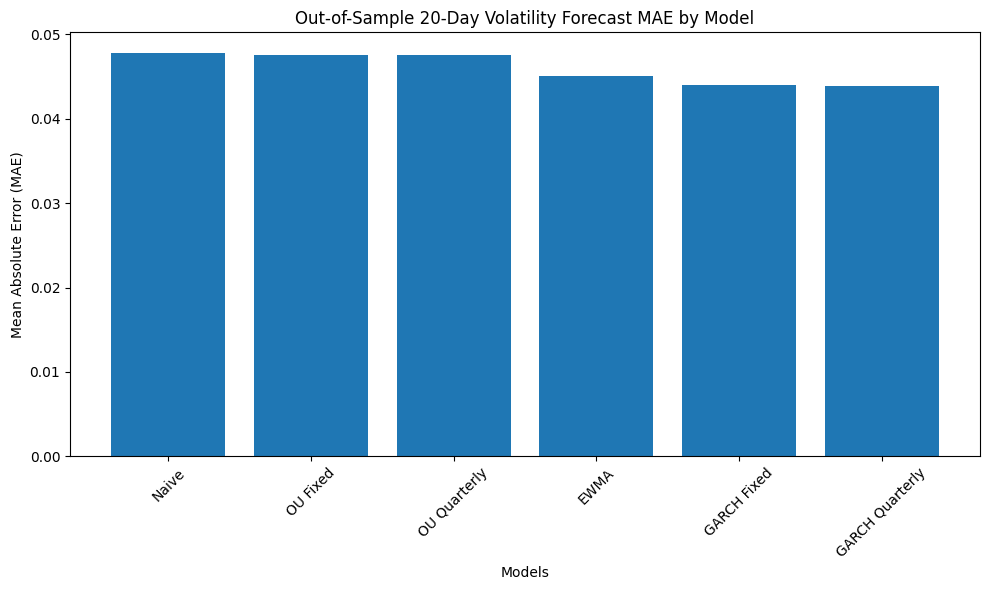

In [149]:
plt.figure(figsize=(10, 6))
plt.bar(result_df["Model"], result_df["MAE"] )

plt.xlabel("Models")
plt.ylabel("Mean Absolute Error (MAE)")
plt.title("Out-of-Sample 20-Day Volatility Forecast MAE by Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

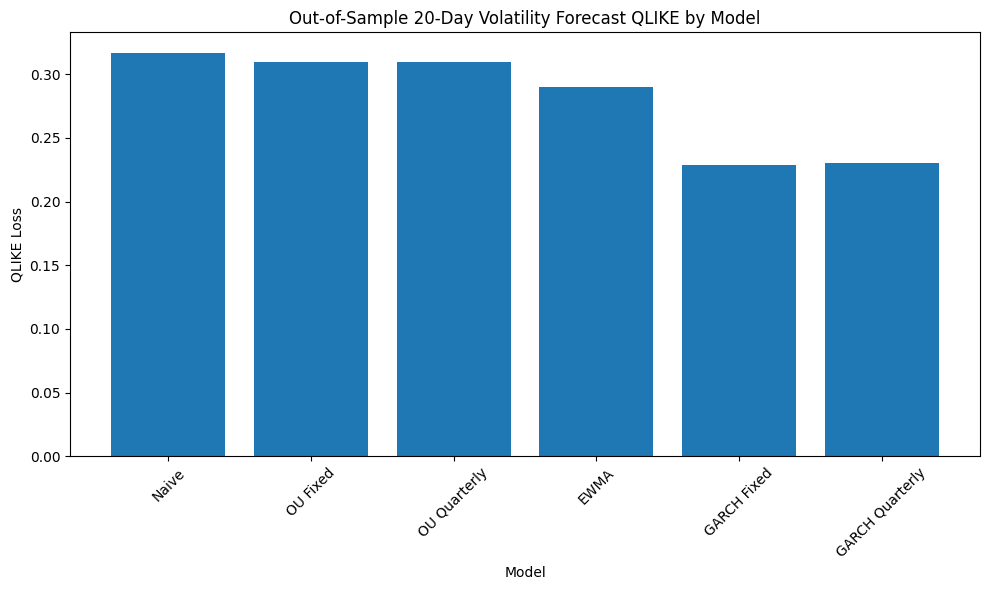

In [150]:
plt.figure(figsize=(10, 6))
plt.bar(result_df["Model"], result_df["QLIKE"] )

plt.xlabel("Model")
plt.ylabel("QLIKE Loss")
plt.title("Out-of-Sample 20-Day Volatility Forecast QLIKE by Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

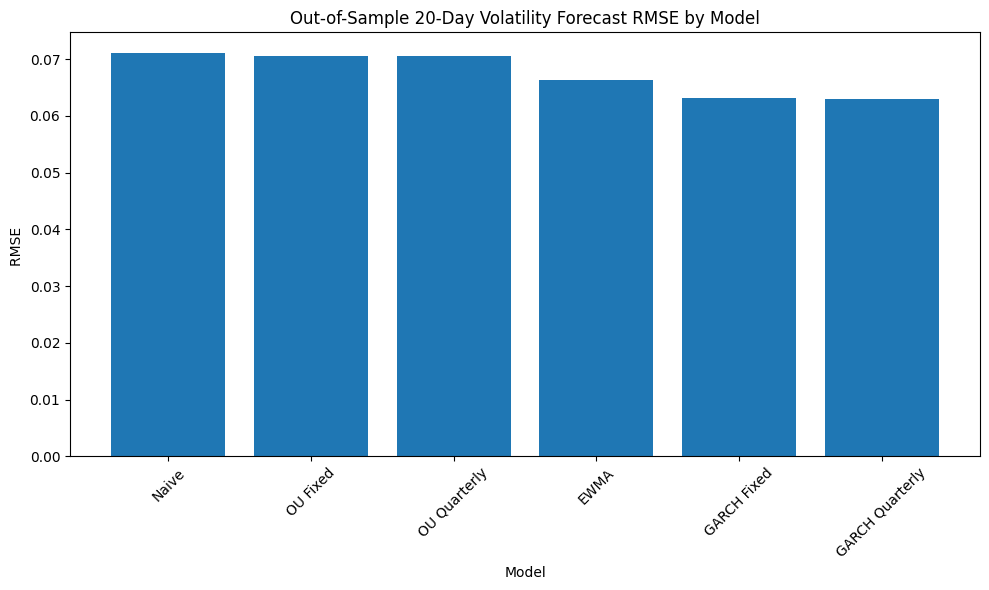

In [151]:
plt.figure(figsize=(10, 6))
plt.bar(result_df["Model"], result_df["RMSE"] )

plt.xlabel("Model")
plt.ylabel("RMSE ")
plt.title("Out-of-Sample 20-Day Volatility Forecast RMSE by Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

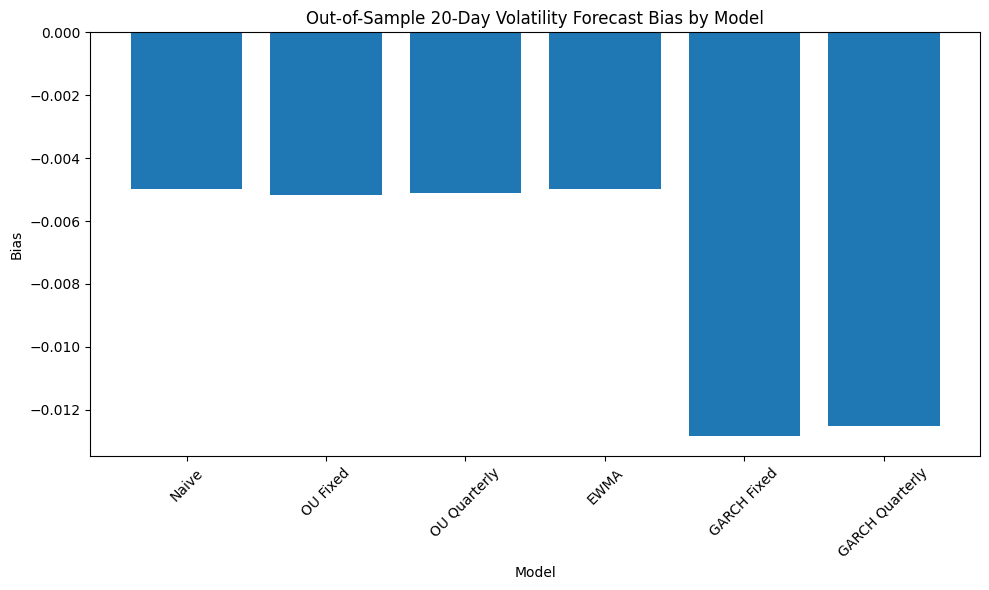

In [152]:
plt.figure(figsize=(10, 6))
plt.bar(result_df["Model"], result_df["Bias"] )

plt.xlabel("Model")
plt.ylabel("Bias")
plt.title("Out-of-Sample 20-Day Volatility Forecast Bias by Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [153]:
def evaluate_regime(actual, forecast, normal_mask, high_mask):
    normal_mae = np.mean(np.abs(actual[normal_mask]- forecast[normal_mask]))
    high_mae = np.mean(np.abs(actual[high_mask]- forecast[high_mask]))
    normal_qlike = qlike(actual[normal_mask], forecast[normal_mask])
    high_qlike = qlike(actual[high_mask], forecast[high_mask])

    return normal_mae, high_mae, normal_qlike, high_qlike



In [154]:
garch_regime_results = evaluate_regime(
    actual_20_vol,
    garch_quarterly_forecasts,
    normal_vol_mask,
    high_vol_mask
)

print(garch_regime_results)

(np.float64(0.0365822255792386), np.float64(0.06594074773305698), np.float64(0.17455352598358534), np.float64(0.3960934961287182))


In [155]:
regime_models = {"Naive": naive_20_forecast,
                 "OU Quarterly": ou_quarterly_forecasts,
                 "EWMA": ewma_20_forecast,
                 "GARCH Quarterly": garch_quarterly_forecasts}

In [156]:
def create_regime_table(actual, models, normal_mask, high_mask):
    rows=[]

    for model_name, forecast in models.items():
        results = evaluate_regime(actual, forecast, normal_mask, high_mask)
        rows.append([model_name, *results])

    return pd.DataFrame(rows,
                        columns=[
                            "Model",
                            "Normal MAE",
                            "High-Vol MAE",
                            "Normal QLIKE",
                            "High-Vol QLIKE"
    ])

In [157]:
regime_df = create_regime_table(
    actual_20_vol,
    regime_models,
    normal_vol_mask,
    high_vol_mask
)

print(regime_df)

             Model  Normal MAE  High-Vol MAE  Normal QLIKE  High-Vol QLIKE
0            Naive    0.038826      0.074886      0.211344        0.633985
1     OU Quarterly    0.038470      0.074631      0.205815        0.621961
2             EWMA    0.036481      0.070851      0.206001        0.543002
3  GARCH Quarterly    0.036582      0.065941      0.174554        0.396093
